In [1]:
import pandas as pd


In [2]:
#1.Загрузить датасет (из Kaggle или другого источника) и вывести первые 10 строк.
df = pd.read_csv('StudentsPerformance.csv')
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [4]:
#2.	Посмотреть .info(), .shape, .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.shape

(1000, 8)

In [6]:
df.size

8000

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
#3.	Вывести список колонок и их типы.
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [10]:
#4.	Проверить на пропущенные значения.
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [11]:
df = df.rename(columns={'race/ethnicity':'race_ethnicity','parental level of education':'parental_level_of_education',
                   'test preparation course':'test_preparation_course','math score':'math_score',
                   'reading score':'reading_score','writing score':'writing_score'})

In [12]:
#5.	Сохранить очищенный датафрейм в students_clean.csv.
df.to_csv('students_clean.csv',index=False)

Pandas 20 tasks

In [13]:
#6.	Сколько уникальных значений у race/ethnicity?
df['race_ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [14]:
count_race = df['race_ethnicity'].nunique()
print(f'Количество уникальных значений у race/ethnicity: {count_race}')

Количество уникальных значений у race/ethnicity: 5


In [15]:
#7.Топ-3 самых высоких средних оценок по математике среди этнических групп.
df.groupby('race_ethnicity')['math_score'].mean().round().sort_values(ascending=False).head(3)

,math_score
race_ethnicity,
group E,74.0
group D,67.0
group C,64.0


In [16]:
df['math_score'].sort_values(ascending=False).head(3)

,math_score
451,100
458,100
962,100


In [17]:
#8.	Сколько учеников прошли курс подготовки (test preparation course)?
df['test_preparation_course'].unique()

array(['none', 'completed'], dtype=object)

In [18]:
count_people = (df['test_preparation_course'] == 'completed').sum()
print(f'Количество учеников прошли курс подготовки: {count_people}')

Количество учеников прошли курс подготовки: 358


In [19]:
df[df['test_preparation_course'] == 'completed']

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
1,female,group C,some college,standard,completed,69,90,88
6,female,group B,some college,standard,completed,88,95,92
8,male,group D,high school,free/reduced,completed,64,64,67
13,male,group A,some college,standard,completed,78,72,70
18,male,group C,master's degree,free/reduced,completed,46,42,46
...,...,...,...,...,...,...,...,...
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
995,female,group E,master's degree,standard,completed,88,99,95
997,female,group C,high school,free/reduced,completed,59,71,65


In [20]:
#9.	Средняя оценка по математике среди тех, кто прошел курс.
df.groupby('test_preparation_course')['math_score'].mean().round()

,math_score
test_preparation_course,
completed,70.0
none,64.0


In [21]:
#10.	Средняя оценка по чтению среди учеников с бесплатным питанием (lunch == free/reduced).
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [22]:
df.groupby('lunch')['reading_score'].mean().round()

,reading_score
lunch,
free/reduced,65.0
standard,72.0


In [23]:
#11.	Сколько учеников с уровнем образования родителей bachelor's degree?
df['parental_level_of_education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [24]:
count_p = (df['parental_level_of_education'] == "bachelor's degree").sum()
print( f"Количество учеников с уровнем образования родителей bachelor's degree: {count_p}")

Количество учеников с уровнем образования родителей bachelor's degree: 118


In [25]:
df[df['parental_level_of_education'] == "bachelor's degree"]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
24,male,group D,bachelor's degree,free/reduced,completed,74,71,80
27,female,group C,bachelor's degree,standard,none,67,69,75
60,male,group E,bachelor's degree,free/reduced,completed,79,74,72
77,male,group A,bachelor's degree,standard,completed,80,78,81
...,...,...,...,...,...,...,...,...
916,male,group E,bachelor's degree,standard,completed,100,100,100
933,male,group C,bachelor's degree,free/reduced,completed,70,75,74
969,female,group B,bachelor's degree,standard,none,75,84,80
970,female,group D,bachelor's degree,standard,none,89,100,100


In [26]:
#12.	Средние баллы по всем предметам по полу (gender).
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [27]:
df['gender'].value_counts(normalize=True).round(2)

,proportion
gender,
female,0.52
male,0.48


In [28]:
df.groupby('gender')['math_score'].mean().round()

,math_score
gender,
female,64.0
male,69.0


In [29]:
df.groupby('gender')['reading_score'].mean().round()

,reading_score
gender,
female,73.0
male,65.0


In [30]:
df.groupby('gender')['writing_score'].mean().round()

,writing_score
gender,
female,72.0
male,63.0


In [31]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean().round()

,math_score,reading_score,writing_score
gender,,,
female,64.0,73.0,72.0
male,69.0,65.0,63.0


In [32]:
#13.	У кого медианная оценка по письму выше — мужчины или женщины?
df.groupby('gender')['writing_score'].median()

,writing_score
gender,
female,74.0
male,64.0


In [33]:
#14.	Средний балл по математике по уровню образования родителей.
df.groupby('parental_level_of_education')['math_score'].mean().round().sort_values(ascending=False)

,math_score
parental_level_of_education,
master's degree,70.0
bachelor's degree,69.0
associate's degree,68.0
some college,67.0
some high school,63.0
high school,62.0


In [34]:
#15.	Группировка по test preparation course и lunch + средние оценки.
df.groupby(['test_preparation_course','lunch'])[['math_score','reading_score','writing_score']].mean().round()

math_score  reading_score  writing_score
test_preparation_course lunch                                                 
completed               free/reduced        63.0           70.0           70.0
                        standard            74.0           76.0           77.0
none                    free/reduced        57.0           62.0           59.0
                        standard            68.0           69.0           68.0

In [35]:
#16.	Найти самого успешного ученика (максимум по сумме 3 оценок).
df['all_scores'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [36]:
df['all_scores'].max()

300

In [37]:
df[df['all_scores'] == 300]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,all_scores
458,female,group E,bachelor's degree,standard,none,100,100,100,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300


In [38]:
#17.	У скольких учеников math score >= 90?
math_top = (df['math_score'] >= 90).sum()
print(f"Количество учеников math score >= 90: {math_top}")

Количество учеников math score >= 90: 58


In [39]:
#18.	У скольких учеников все три оценки больше 80?
all_three_top = (df['all_scores'] > 80).sum()
print(f"Количество учеников все три оценки больше 80: {all_three_top}")

Количество учеников все три оценки больше 80: 994


In [40]:
#19.	Группировка по gender, race/ethnicity, mean().
df.groupby(['gender', 'race_ethnicity'])[['math_score','reading_score','writing_score']].mean().round()


math_score  reading_score  writing_score
gender race_ethnicity                                          
female group A               59.0           69.0           68.0
       group B               61.0           71.0           70.0
       group C               62.0           72.0           72.0
       group D               65.0           74.0           75.0
       group E               71.0           76.0           76.0
male   group A               64.0           62.0           59.0
       group B               66.0           63.0           60.0
       group C               68.0           65.0           63.0
       group D               69.0           66.0           65.0
       group E               77.0           70.0           67.0

In [41]:
#20.	Создать новый столбец average_score = среднее из трех оценок.
df['average_score'] = round(df['all_scores']/3)
df


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,all_scores,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,73.0
1,female,group C,some college,standard,completed,69,90,88,247,82.0
2,female,group B,master's degree,standard,none,90,95,93,278,93.0
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.0
4,male,group C,some college,standard,none,76,78,75,229,76.0
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.0
996,male,group C,high school,free/reduced,none,62,55,55,172,57.0
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.0
998,female,group D,some college,standard,completed,68,78,77,223,74.0


График: Seaborn, Matplotib

In [42]:
#41.	Построить histplot для math score.
import matplotlib.pyplot as plt
import seaborn as sns


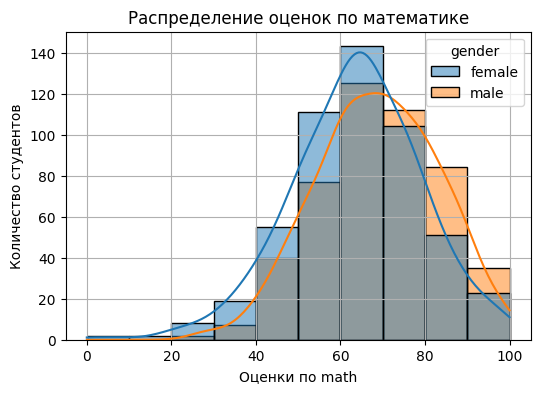

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(data= df, x = 'math_score', bins=10, kde=True, hue='gender')
plt.title('Распределение оценок по математике')
plt.xlabel('Оценки по math')
plt.ylabel('Количество студентов')
plt.grid()
plt.savefig('math_score.png')
plt.show()

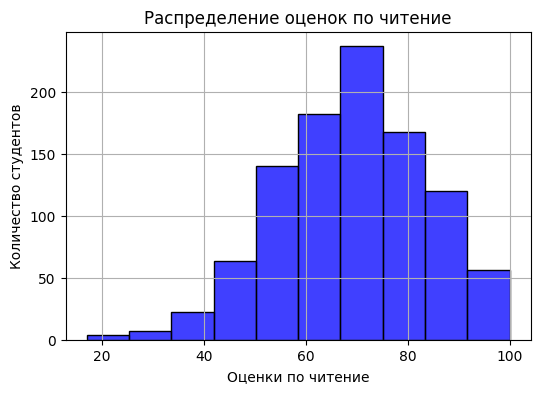

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(data= df, x = 'reading_score', bins=10, color='blue')
plt.title('Распределение оценок по читение')
plt.xlabel('Оценки по читение')
plt.ylabel('Количество студентов')
plt.grid()
plt.savefig('reading_score.png')
plt.show()

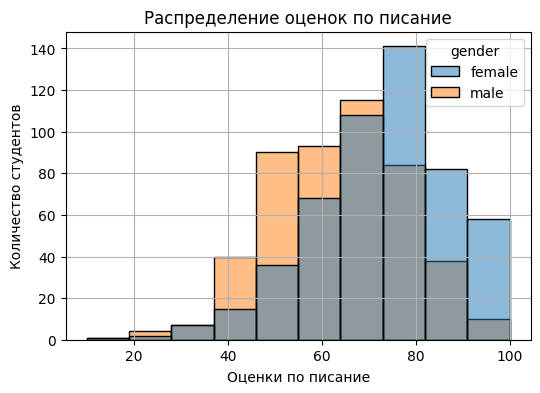

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(data= df, x = 'writing_score', bins=10, hue='gender', color='red')
plt.title('Распределение оценок по писание')
plt.xlabel('Оценки по писание')
plt.ylabel('Количество студентов')
plt.grid()
plt.savefig('writing_score.png')
plt.show()

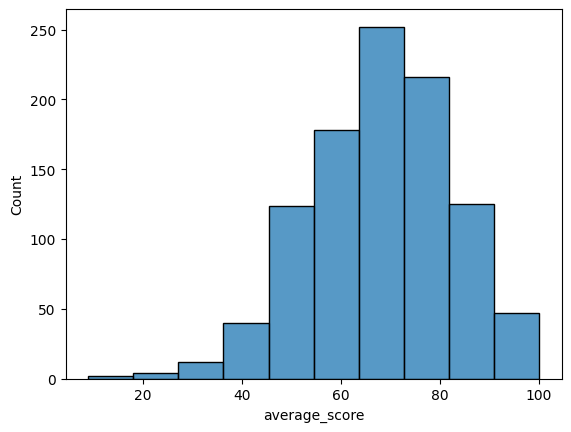

In [46]:
#42.	Распределение average_score.
sns.histplot(data= df, x = 'average_score', bins=10)
plt.show()

MATH_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

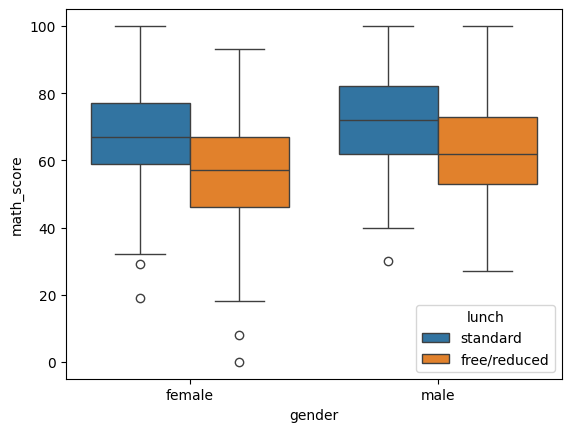

In [47]:
#43.	boxplot: gender vs math score.
sns.boxplot(data=df, x='gender', y='math_score', hue='lunch')
plt.show()

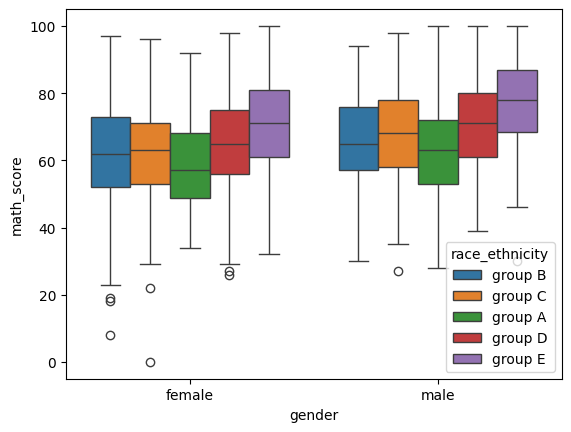

In [48]:
sns.boxplot(data=df, x='gender', y='math_score', hue='race_ethnicity')
plt.show()

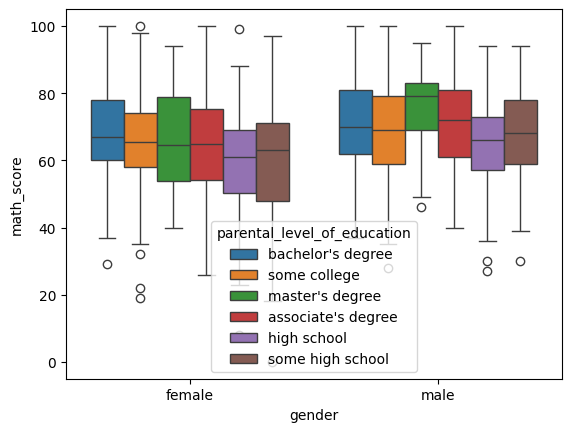

In [49]:
sns.boxplot(data=df, x='gender', y='math_score',hue='parental_level_of_education')
plt.show()

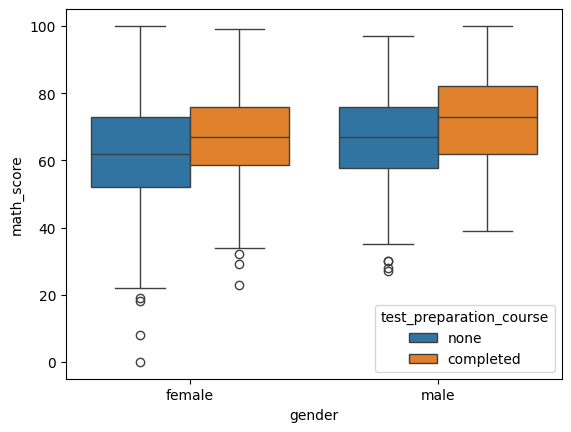

In [50]:
sns.boxplot(data=df, x='gender', y='math_score', hue='test_preparation_course')
plt.show()

In [51]:
df.groupby('gender')['math_score'].describe().round()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,518.0,64.0,15.0,0.0,54.0,65.0,74.0,100.0
male,482.0,69.0,14.0,27.0,59.0,69.0,79.0,100.0


READING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

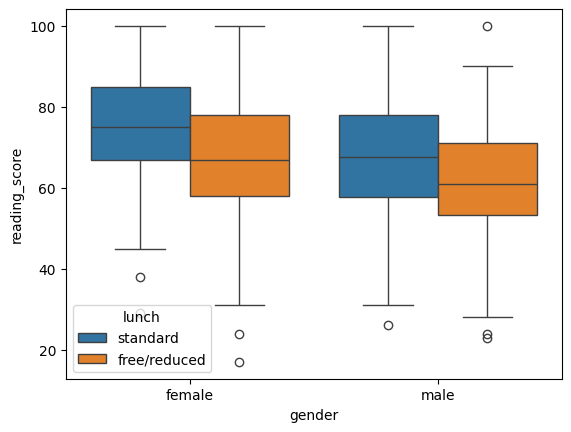

In [52]:
sns.boxplot(data=df, x='gender', y='reading_score', hue='lunch')
plt.show()

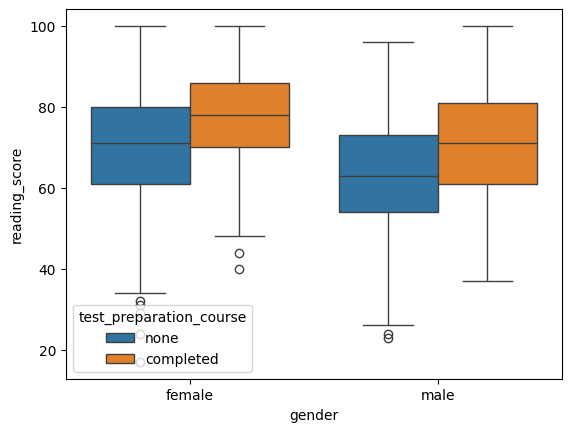

In [53]:
sns.boxplot(data=df, x='gender', y='reading_score', hue='test_preparation_course')
plt.show()

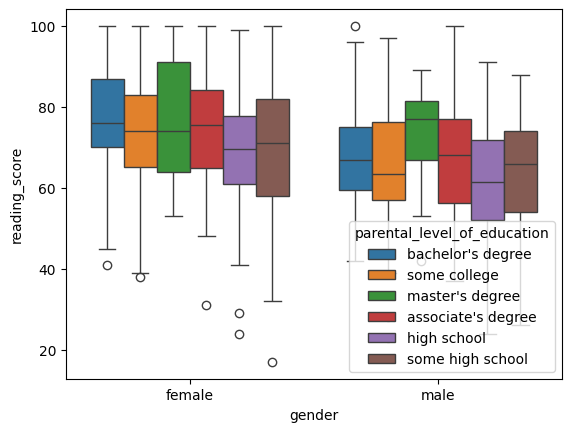

In [54]:
sns.boxplot(data=df, x='gender', y='reading_score', hue='parental_level_of_education')
plt.show()

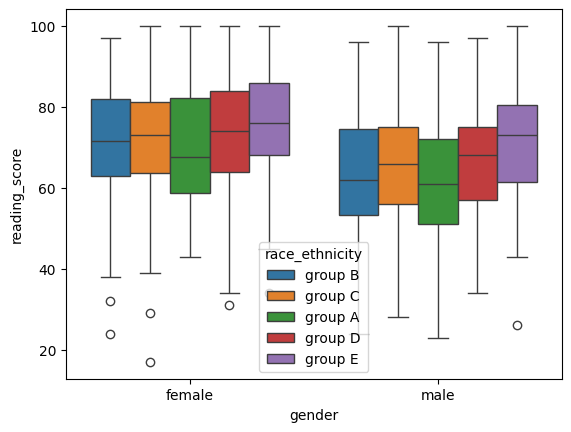

In [55]:
sns.boxplot(data=df, x='gender', y='reading_score', hue='race_ethnicity')
plt.show()

In [56]:
df.groupby('gender')['reading_score'].describe().round()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,518.0,73.0,14.0,17.0,63.0,73.0,83.0,100.0
male,482.0,65.0,14.0,23.0,56.0,66.0,75.0,100.0


WRITING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

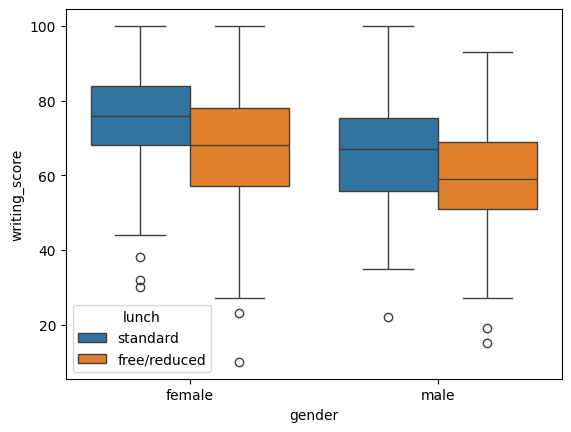

In [57]:
sns.boxplot(data=df, x='gender', y='writing_score', hue='lunch')
plt.show()

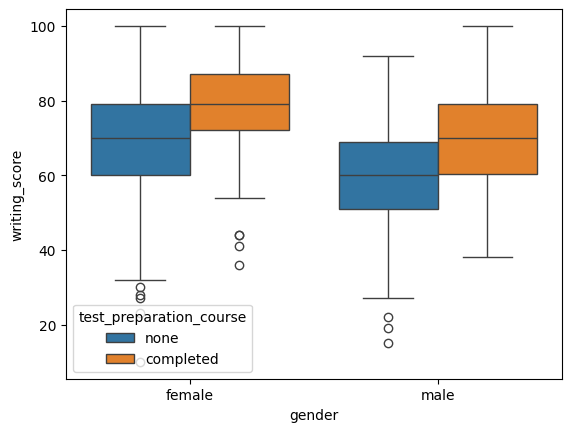

In [58]:
sns.boxplot(data=df, x='gender', y='writing_score', hue='test_preparation_course')
plt.show()

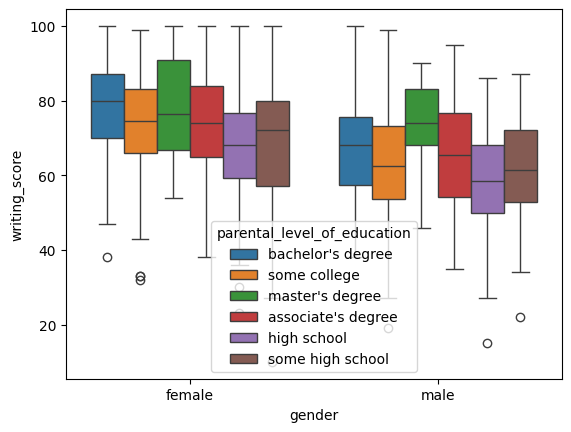

In [59]:
sns.boxplot(data=df, x='gender', y='writing_score', hue='parental_level_of_education')
plt.show()

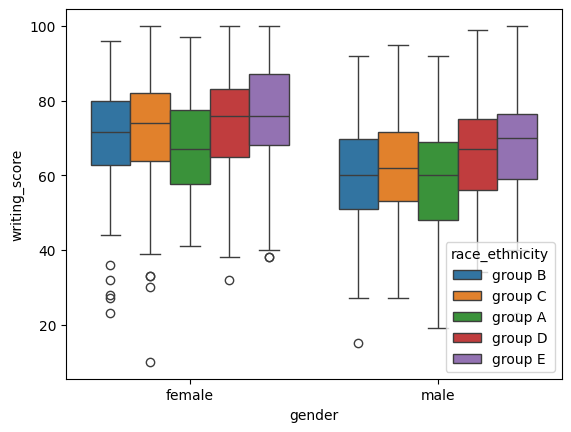

In [60]:
sns.boxplot(data=df, x='gender', y='writing_score', hue='race_ethnicity')
plt.show()

In [61]:
df.groupby('gender')['writing_score'].describe().round()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,518.0,72.0,15.0,10.0,64.0,74.0,82.0,100.0
male,482.0,63.0,14.0,15.0,53.0,64.0,74.0,100.0


 VIOLINPLOT --- WRITING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

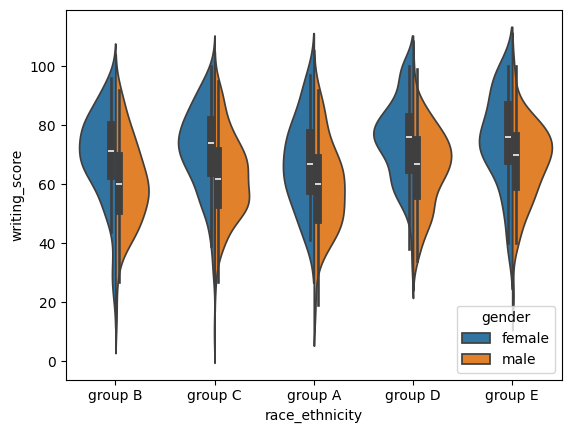

In [62]:
#44.	violinplot: race/ethnicity vs writing score.
sns.violinplot(data=df, x='race_ethnicity', y='writing_score', hue='gender', split=True)
plt.show()


In [63]:
df.groupby(['gender','race_ethnicity'])['writing_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender race_ethnicity                                                  
female group A          36.0  68.0  15.0  41.0  58.0  67.0  78.0   97.0
       group B         104.0  70.0  15.0  23.0  63.0  72.0  80.0   96.0
       group C         180.0  72.0  15.0  10.0  64.0  74.0  82.0  100.0
       group D         129.0  75.0  14.0  32.0  65.0  76.0  83.0  100.0
       group E          69.0  76.0  16.0  38.0  68.0  76.0  87.0  100.0
male   group A          53.0  59.0  15.0  19.0  48.0  60.0  69.0   92.0
       group B          86.0  60.0  15.0  15.0  51.0  60.0  70.0   92.0
       group C         139.0  63.0  14.0  27.0  53.0  62.0  72.0   95.0
       group D         133.0  65.0  13.0  34.0  56.0  67.0  75.0   99.0
       group E          71.0  67.0  13.0  22.0  59.0  70.0  76.0  100.0

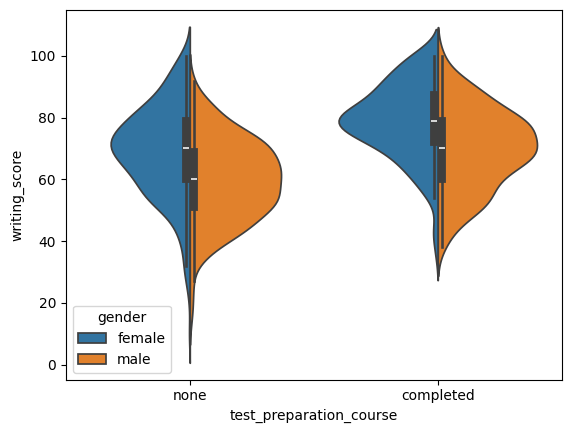

In [64]:
sns.violinplot(data=df, x='test_preparation_course', y='writing_score', hue='gender', split=True)
plt.show()

In [65]:
df.groupby(['gender','test_preparation_course'])['writing_score'].describe().round()

count  mean   std   min   25%   50%   75%  \
gender test_preparation_course                                              
female completed                184.0  79.0  12.0  36.0  72.0  79.0  87.0   
       none                     334.0  69.0  15.0  10.0  60.0  70.0  79.0   
male   completed                174.0  70.0  13.0  38.0  60.0  70.0  79.0   
       none                     308.0  60.0  13.0  15.0  51.0  60.0  69.0   

                                  max  
gender test_preparation_course         
female completed                100.0  
       none                     100.0  
male   completed                100.0  
       none                      92.0

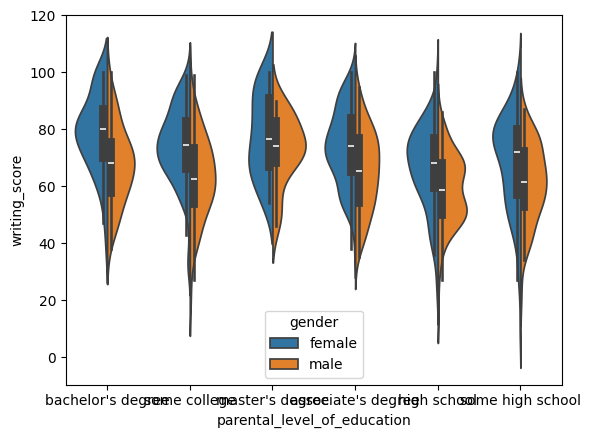

In [66]:
sns.violinplot(data=df, x='parental_level_of_education', y='writing_score', hue='gender', split=True)
plt.show()

In [67]:
df.groupby(['gender','parental_level_of_education'])['writing_score'].describe().round()

count  mean   std   min   25%   50%   75%  \
gender parental_level_of_education                                              
female associate's degree           116.0  74.0  13.0  38.0  65.0  74.0  84.0   
       bachelor's degree             63.0  78.0  14.0  38.0  70.0  80.0  87.0   
       high school                   94.0  67.0  14.0  23.0  59.0  68.0  77.0   
       master's degree               36.0  78.0  15.0  54.0  67.0  76.0  91.0   
       some college                 118.0  74.0  13.0  32.0  66.0  74.0  83.0   
       some high school              91.0  68.0  17.0  10.0  57.0  72.0  80.0   
male   associate's degree           106.0  65.0  14.0  35.0  54.0  66.0  77.0   
       bachelor's degree             55.0  68.0  14.0  38.0  58.0  68.0  76.0   
       high school                  102.0  59.0  13.0  15.0  50.0  58.0  68.0   
       master's degree               23.0  73.0  12.0  46.0  68.0  74.0  83.0   
       some college                 108.0  63.0  15.0  19.0  54.0  62.0  73.0   
       some high school              88.0  61.0  14.0  22.0  53.0  62.0  72.0   

                                      max  
gender parental_level_of_education         
female associate's degree           100.0  
       bachelor's degree            100.0  
       high school                  100.0  
       master's degree              100.0  
       some college                  99.0  
       some high school             100.0  
male   associate's degree            95.0  
       bachelor's degree            100.0  
       high school                   86.0  
       master's degree               90.0  
       some college                  99.0  
       some high school              87.0

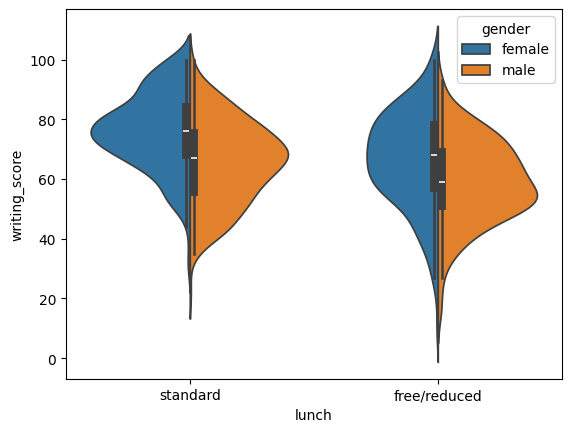

In [68]:
sns.violinplot(data=df, x='lunch', y='writing_score', hue='gender', split=True)
plt.show()

In [69]:
df.groupby(['gender','lunch'])['writing_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender lunch                                                         
female free/reduced  189.0  66.0  16.0  10.0  57.0  68.0  78.0  100.0
       standard      329.0  76.0  13.0  30.0  68.0  76.0  84.0  100.0
male   free/reduced  166.0  59.0  14.0  15.0  51.0  59.0  69.0   93.0
       standard      316.0  66.0  14.0  22.0  56.0  67.0  75.0  100.0


READING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

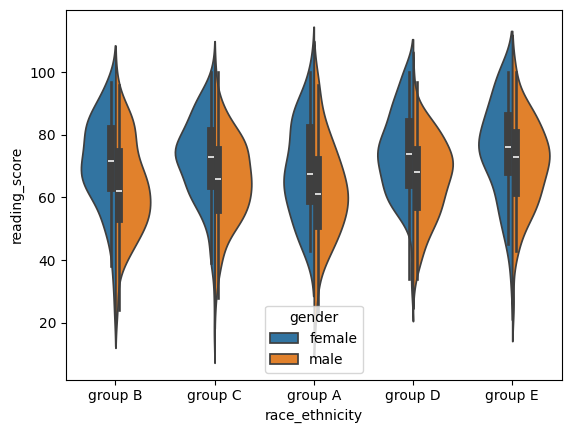

In [70]:
sns.violinplot(data=df, x='race_ethnicity', y='reading_score', hue='gender', split=True)
plt.show()

In [71]:
df.groupby(['gender','race_ethnicity'])['reading_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender race_ethnicity                                                  
female group A          36.0  69.0  15.0  43.0  59.0  68.0  82.0  100.0
       group B         104.0  71.0  15.0  24.0  63.0  72.0  82.0   97.0
       group C         180.0  72.0  14.0  17.0  64.0  73.0  81.0  100.0
       group D         129.0  74.0  14.0  31.0  64.0  74.0  84.0  100.0
       group E          69.0  76.0  15.0  34.0  68.0  76.0  86.0  100.0
male   group A          53.0  62.0  15.0  23.0  51.0  61.0  72.0   96.0
       group B          86.0  63.0  15.0  24.0  53.0  62.0  74.0   96.0
       group C         139.0  65.0  13.0  28.0  56.0  66.0  75.0  100.0
       group D         133.0  66.0  13.0  34.0  57.0  68.0  75.0   97.0
       group E          71.0  70.0  14.0  26.0  62.0  73.0  80.0  100.0

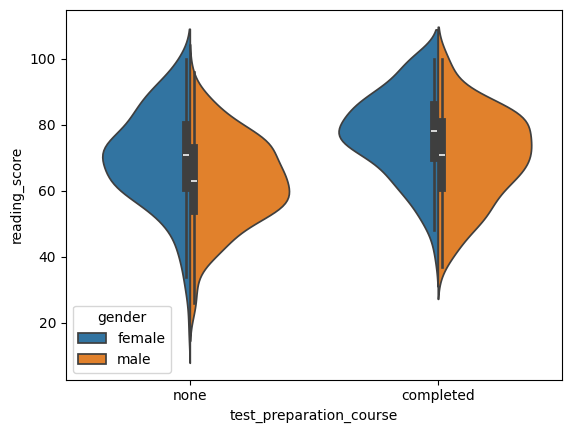

In [72]:
sns.violinplot(data=df, x='test_preparation_course', y='reading_score', hue='gender', split=True)
plt.show()

In [73]:
df.groupby(['gender','test_preparation_course'])['reading_score'].describe().round()

count  mean   std   min   25%   50%   75%  \
gender test_preparation_course                                              
female completed                184.0  77.0  13.0  40.0  70.0  78.0  86.0   
       none                     334.0  70.0  15.0  17.0  61.0  71.0  80.0   
male   completed                174.0  70.0  14.0  37.0  61.0  71.0  81.0   
       none                     308.0  63.0  13.0  23.0  54.0  63.0  73.0   

                                  max  
gender test_preparation_course         
female completed                100.0  
       none                     100.0  
male   completed                100.0  
       none                      96.0

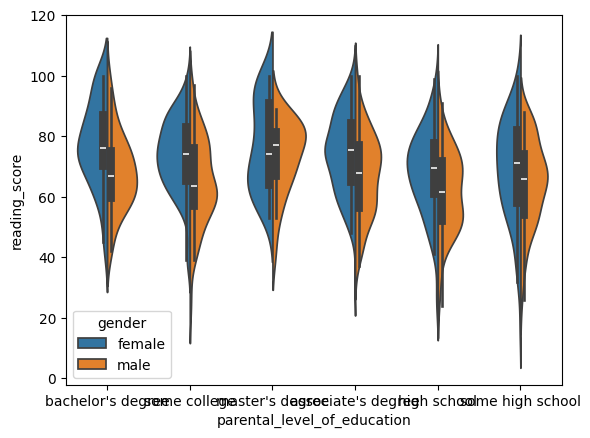

In [74]:
sns.violinplot(data=df, x='parental_level_of_education', y='reading_score', hue='gender', split=True)
plt.show()

In [75]:
df.groupby(['parental_level_of_education'])['reading_score'].describe().round()

,count,mean,std,min,25%,50%,75%,max
parental_level_of_education,,,,,,,,
associate's degree,222.0,71.0,14.0,31.0,61.0,72.0,81.0,100.0
bachelor's degree,118.0,73.0,14.0,41.0,63.0,73.0,83.0,100.0
high school,196.0,65.0,14.0,24.0,54.0,66.0,74.0,99.0
master's degree,59.0,75.0,14.0,42.0,66.0,76.0,84.0,100.0
some college,226.0,69.0,14.0,23.0,60.0,70.0,80.0,100.0
some high school,179.0,67.0,15.0,17.0,56.0,67.0,79.0,100.0


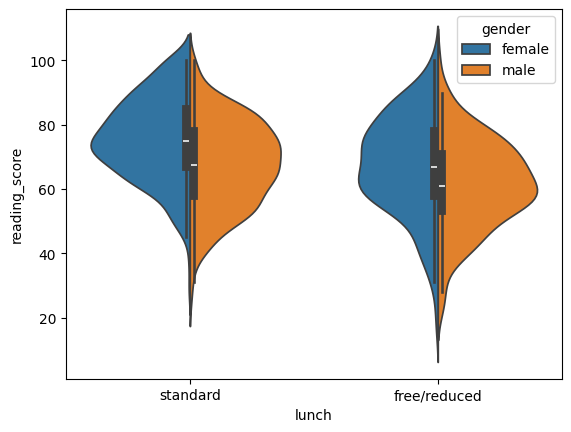

In [76]:
sns.violinplot(data=df, x='lunch', y='reading_score', hue='gender', split=True)
plt.show()

In [77]:
df.groupby(['gender','lunch'])['reading_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender lunch                                                         
female free/reduced  189.0  67.0  15.0  17.0  58.0  67.0  78.0  100.0
       standard      329.0  76.0  13.0  29.0  67.0  75.0  85.0  100.0
male   free/reduced  166.0  62.0  14.0  23.0  53.0  61.0  71.0  100.0
       standard      316.0  68.0  14.0  26.0  58.0  68.0  78.0  100.0

MATH_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

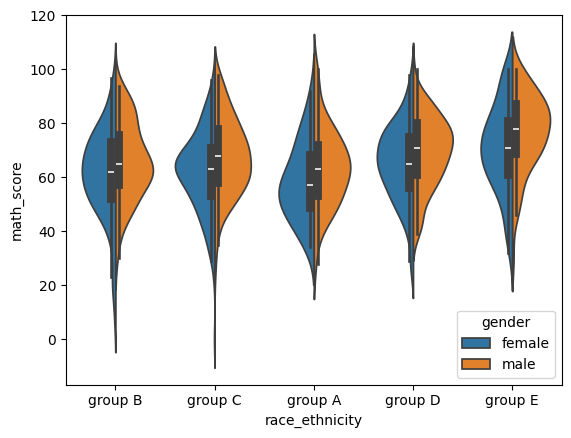

In [78]:
sns.violinplot(data=df, x='race_ethnicity', y='math_score', hue='gender', split=True)
plt.show()

In [79]:
df.groupby(['gender','race_ethnicity'])['math_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender race_ethnicity                                                  
female group A          36.0  59.0  14.0  34.0  49.0  57.0  68.0   92.0
       group B         104.0  61.0  16.0   8.0  52.0  62.0  73.0   97.0
       group C         180.0  62.0  15.0   0.0  53.0  63.0  71.0   96.0
       group D         129.0  65.0  14.0  26.0  56.0  65.0  75.0   98.0
       group E          69.0  71.0  16.0  32.0  61.0  71.0  81.0  100.0
male   group A          53.0  64.0  15.0  28.0  53.0  63.0  72.0  100.0
       group B          86.0  66.0  14.0  30.0  57.0  65.0  76.0   94.0
       group C         139.0  68.0  14.0  27.0  58.0  68.0  78.0   98.0
       group D         133.0  69.0  13.0  39.0  61.0  71.0  80.0  100.0
       group E          71.0  77.0  14.0  30.0  68.0  78.0  87.0  100.0

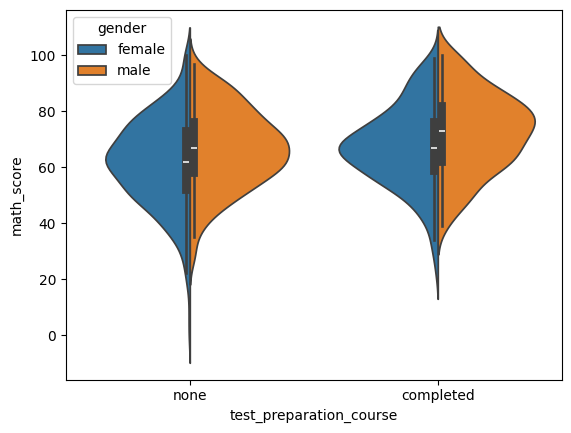

In [80]:
sns.violinplot(data=df, x='test_preparation_course', y='math_score', hue='gender', split=True)
plt.show()

In [81]:
df.groupby(['gender','test_preparation_course'])['math_score'].describe().round()

count  mean   std   min   25%   50%   75%  \
gender test_preparation_course                                              
female completed                184.0  67.0  14.0  23.0  59.0  67.0  76.0   
       none                     334.0  62.0  16.0   0.0  52.0  62.0  73.0   
male   completed                174.0  72.0  14.0  39.0  62.0  73.0  82.0   
       none                     308.0  67.0  14.0  27.0  58.0  67.0  76.0   

                                  max  
gender test_preparation_course         
female completed                 99.0  
       none                     100.0  
male   completed                100.0  
       none                      97.0

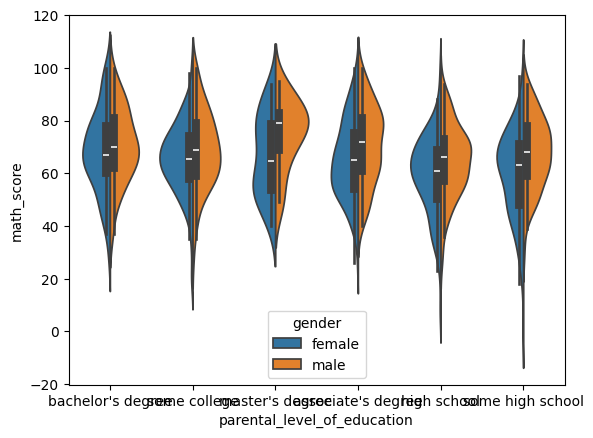

In [82]:
sns.violinplot(data=df, x='parental_level_of_education', y='math_score', hue='gender', split=True)
plt.show()

In [83]:
df.groupby(['gender','parental_level_of_education'])['math_score'].describe().round()

count  mean   std   min   25%   50%   75%  \
gender parental_level_of_education                                              
female associate's degree           116.0  65.0  15.0  26.0  54.0  65.0  75.0   
       bachelor's degree             63.0  68.0  16.0  29.0  60.0  67.0  78.0   
       high school                   94.0  59.0  15.0   8.0  50.0  61.0  69.0   
       master's degree               36.0  66.0  16.0  40.0  54.0  64.0  79.0   
       some college                 118.0  65.0  14.0  19.0  58.0  66.0  74.0   
       some high school              91.0  59.0  17.0   0.0  48.0  63.0  71.0   
male   associate's degree           106.0  71.0  15.0  40.0  61.0  72.0  81.0   
       bachelor's degree             55.0  71.0  14.0  37.0  62.0  70.0  81.0   
       high school                  102.0  65.0  14.0  27.0  57.0  66.0  73.0   
       master's degree               23.0  75.0  13.0  46.0  69.0  79.0  83.0   
       some college                 108.0  69.0  15.0  28.0  59.0  69.0  79.0   
       some high school              88.0  68.0  14.0  30.0  59.0  68.0  78.0   

                                      max  
gender parental_level_of_education         
female associate's degree           100.0  
       bachelor's degree            100.0  
       high school                   99.0  
       master's degree               94.0  
       some college                 100.0  
       some high school              97.0  
male   associate's degree           100.0  
       bachelor's degree            100.0  
       high school                   94.0  
       master's degree               95.0  
       some college                 100.0  
       some high school              94.0

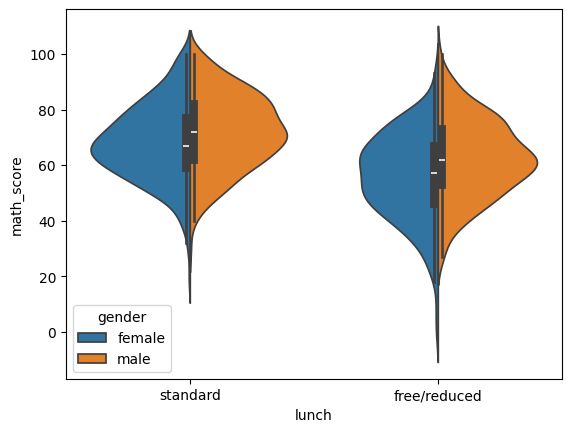

In [84]:
sns.violinplot(data=df, x='lunch', y='math_score', hue='gender', split=True)
plt.show()

In [85]:
df.groupby(['gender','lunch'])['writing_score'].describe().round()

count  mean   std   min   25%   50%   75%    max
gender lunch                                                         
female free/reduced  189.0  66.0  16.0  10.0  57.0  68.0  78.0  100.0
       standard      329.0  76.0  13.0  30.0  68.0  76.0  84.0  100.0
male   free/reduced  166.0  59.0  14.0  15.0  51.0  59.0  69.0   93.0
       standard      316.0  66.0  14.0  22.0  56.0  67.0  75.0  100.0

BARPLOT>>

MATH_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

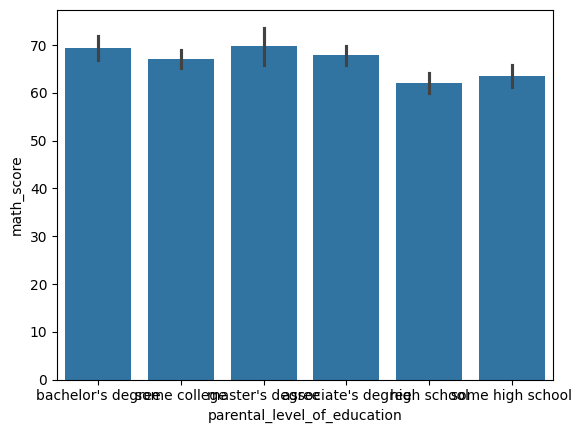

In [86]:
#45.	barplot: средние оценки по parental level of education.
sns.barplot(data=df, x='parental_level_of_education', y='math_score')
plt.show()

In [87]:
df.groupby(['parental_level_of_education'])['math_score'].mean().round()

,math_score
parental_level_of_education,
associate's degree,68.0
bachelor's degree,69.0
high school,62.0
master's degree,70.0
some college,67.0
some high school,63.0


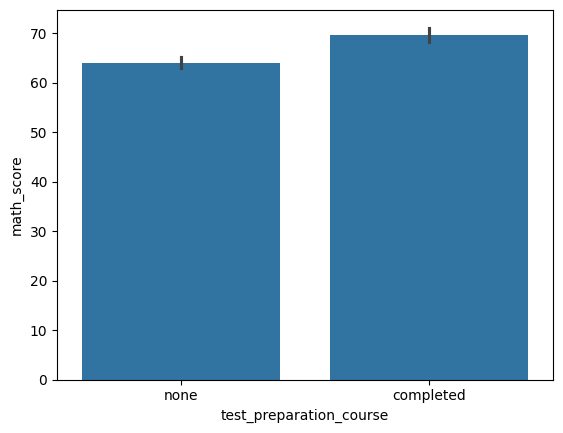

In [88]:
sns.barplot(data=df, x='test_preparation_course', y='math_score')
plt.show()


In [89]:
df.groupby(['test_preparation_course'])['math_score'].mean().round()

,math_score
test_preparation_course,
completed,70.0
none,64.0


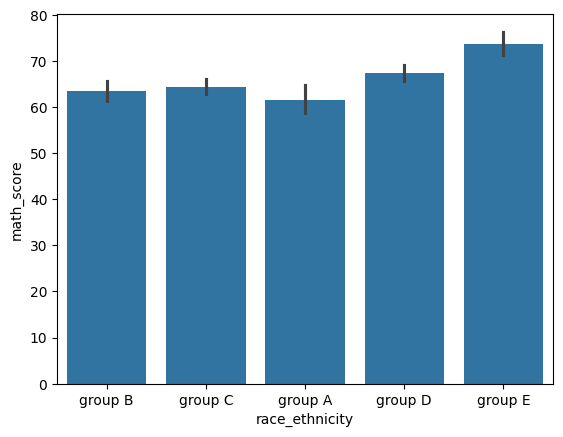

In [90]:
sns.barplot(data=df, x='race_ethnicity', y='math_score')
plt.show()

In [91]:
df.groupby(['race_ethnicity'])['math_score'].mean().round()


,math_score
race_ethnicity,
group A,62.0
group B,63.0
group C,64.0
group D,67.0
group E,74.0


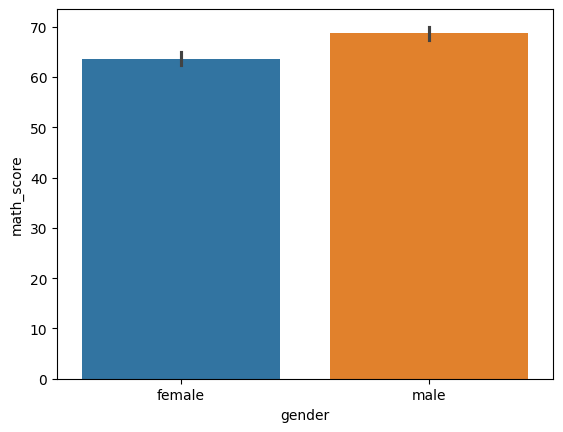

In [92]:
sns.barplot(data=df, x='gender', y='math_score',hue='gender')
plt.show()

In [93]:
df.groupby(['gender'])['math_score'].mean().round()

,math_score
gender,
female,64.0
male,69.0


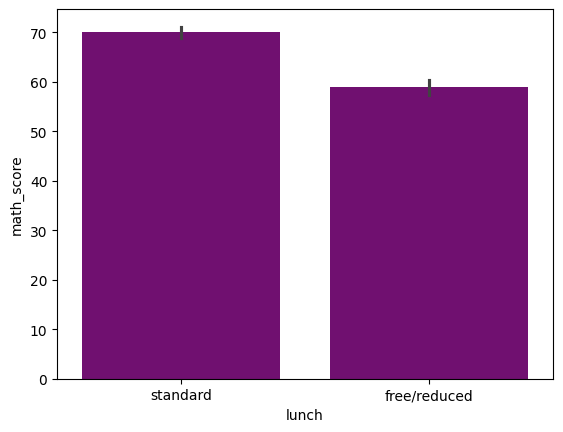

In [94]:
sns.barplot(data=df, x='lunch', y='math_score', color='purple')
plt.show()

In [95]:
df.groupby(['lunch'])['math_score'].mean().round()

,math_score
lunch,
free/reduced,59.0
standard,70.0



READING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

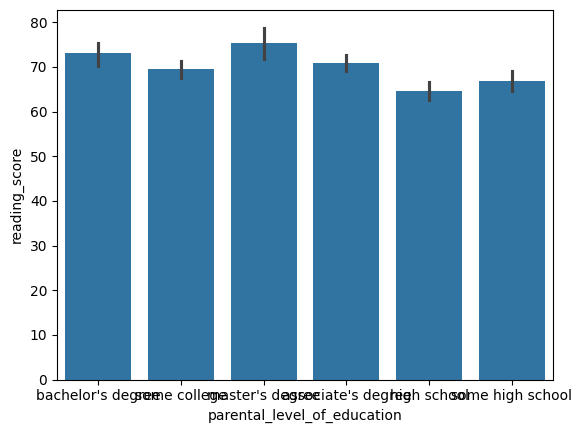

In [96]:
sns.barplot(data=df, x='parental_level_of_education', y='reading_score')
plt.show()

In [97]:
df.groupby(['parental_level_of_education'])['reading_score'].mean().round()


,reading_score
parental_level_of_education,
associate's degree,71.0
bachelor's degree,73.0
high school,65.0
master's degree,75.0
some college,69.0
some high school,67.0


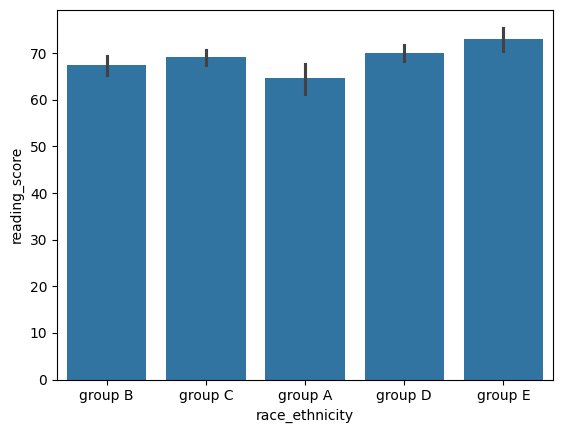

In [98]:
sns.barplot(data=df, x='race_ethnicity', y='reading_score')
plt.show()

In [99]:
df.groupby(['race_ethnicity'])['reading_score'].mean().round()

,reading_score
race_ethnicity,
group A,65.0
group B,67.0
group C,69.0
group D,70.0
group E,73.0


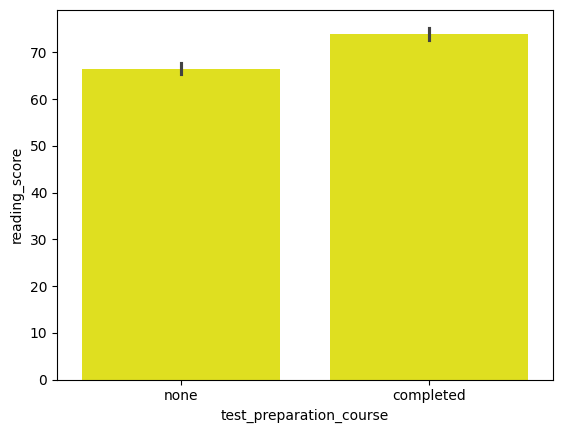

In [101]:
sns.barplot(data=df, x='test_preparation_course', y='reading_score',color='yellow')
plt.show()

In [102]:
df.groupby(['test_preparation_course'])['reading_score'].mean().round()


,reading_score
test_preparation_course,
completed,74.0
none,67.0


/tmp/ipykernel_219/464703647.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  sns.barplot(data=df, x='gender', y='reading_score',hue='gender',color='pink')


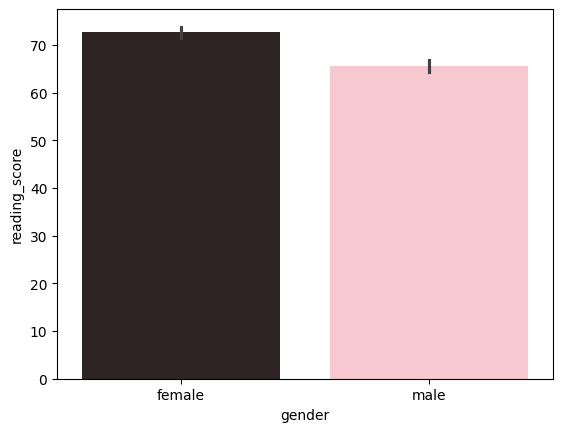

In [103]:
sns.barplot(data=df, x='gender', y='reading_score',hue='gender',color='pink')
plt.show()

In [104]:
df.groupby(['gender'])['reading_score'].mean().round()

,reading_score
gender,
female,73.0
male,65.0


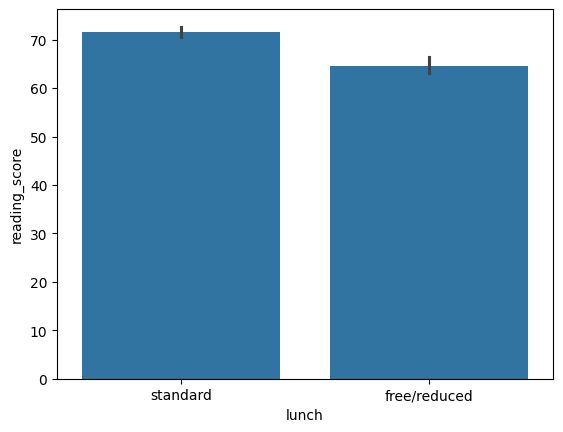

In [105]:
sns.barplot(data=df, x='lunch', y='reading_score')
plt.show()

In [106]:
df.groupby(['lunch'])['reading_score'].mean().round()

,reading_score
lunch,
free/reduced,65.0
standard,72.0


WRITING_SCORE (GENDER, RACE, TEST, LUNCH, PARENTAL)

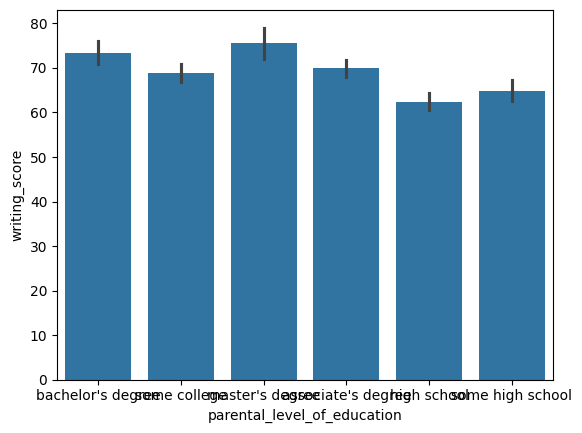

In [107]:
sns.barplot(data=df, x='parental_level_of_education', y='writing_score')
plt.show()

In [108]:
df.groupby(['parental_level_of_education'])['writing_score'].mean().round()

,writing_score
parental_level_of_education,
associate's degree,70.0
bachelor's degree,73.0
high school,62.0
master's degree,76.0
some college,69.0
some high school,65.0


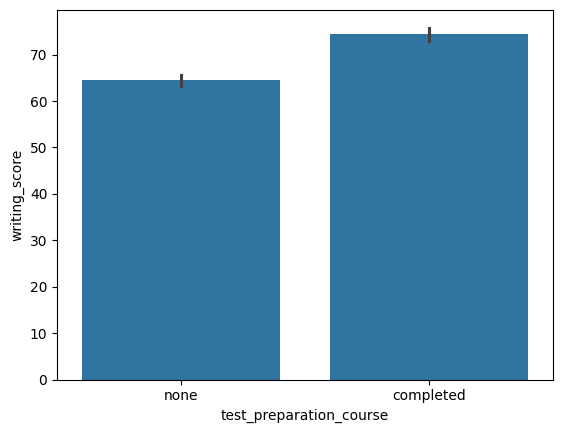

In [109]:
sns.barplot(data=df, x='test_preparation_course', y='writing_score')
plt.show()

In [110]:
df.groupby(['test_preparation_course'])['writing_score'].mean().round()

,writing_score
test_preparation_course,
completed,74.0
none,65.0


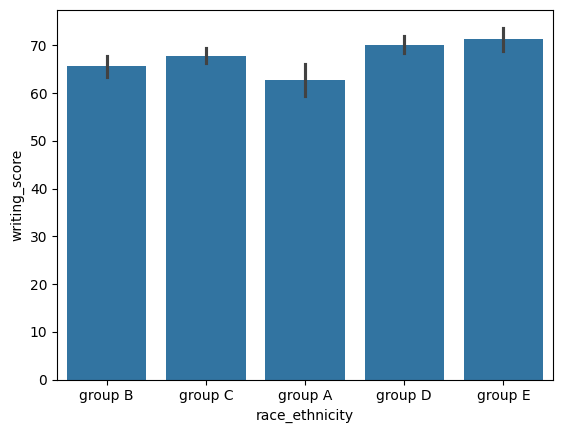

In [111]:
sns.barplot(data=df, x='race_ethnicity', y='writing_score')
plt.show()

In [112]:
df.groupby(['race_ethnicity'])['writing_score'].mean().round()

,writing_score
race_ethnicity,
group A,63.0
group B,66.0
group C,68.0
group D,70.0
group E,71.0


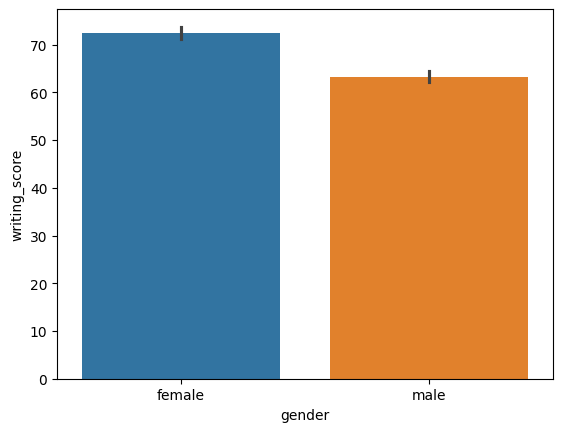

In [113]:
sns.barplot(data=df, x='gender', y='writing_score', hue='gender')
plt.show()

In [114]:
df.groupby(['gender'])['writing_score'].mean().round()

,writing_score
gender,
female,72.0
male,63.0


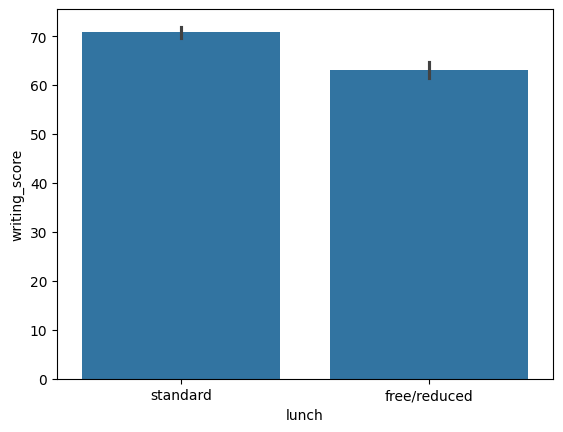

In [115]:
sns.barplot(data=df, x='lunch', y='writing_score')
plt.show()

In [116]:
df.groupby(['lunch'])['writing_score'].mean().round()

,writing_score
lunch,
free/reduced,63.0
standard,71.0


In [117]:
df = df.drop(columns=['all_scores','average_score'])

In [202]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [118]:
#51.	Закодировать категориальные переменные (LabelEncoder или OneHot).
df = pd.get_dummies(df, columns=['gender', 'race_ethnicity', 'parental_level_of_education',
                            'test_preparation_course', 'lunch'], drop_first=True).astype(int)



In [119]:

#52.	Нормализовать числовые признаки (StandardScaler).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_data = scaler.fit_transform(df.drop(columns='writing_score'))

In [120]:
scaler_data

array([[ 0.39002351,  0.19399858, -0.96462528, ..., -0.4669334 ,
         0.74674788,  0.74188112],
       [ 0.19207553,  1.42747598, -0.96462528, ..., -0.4669334 ,
        -1.33914006,  0.74188112],
       [ 1.57771141,  1.77010859, -0.96462528, ..., -0.4669334 ,
         0.74674788,  0.74188112],
       ...,
       [-0.46775108,  0.12547206, -0.96462528, ..., -0.4669334 ,
        -1.33914006, -1.34792485],
       [ 0.12609287,  0.60515772, -0.96462528, ..., -0.4669334 ,
        -1.33914006,  0.74188112],
       [ 0.71993682,  1.15336989, -0.96462528, ..., -0.4669334 ,
         0.74674788, -1.34792485]])

In [121]:
#53.	Проверить и удалить выбросы по average_score.
#54.	Разделить X и y (y = math score).
x = scaler_data
y = df['writing_score']


In [122]:
#55.	Сделать train/test split (80/20).
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)



In [123]:
#56.	Построить LinearRegression() модель.
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()



In [124]:
#57.	Обучить модель на тренировочных данных.
lin_model.fit(x_train, y_train)

LinearRegression()

In [125]:
#58.	Предсказать на тестовой выборке.
y_pred = lin_model.predict(x_test)

In [126]:
#59.	Вычислить метрики: MAE, MSE, RMSE, R².
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)


0.9344772753176349

In [127]:
import joblib

joblib.dump(lin_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [128]:
df.columns

Index(['math_score', 'reading_score', 'writing_score', 'gender_male',
       'race_ethnicity_group B', 'race_ethnicity_group C',
       'race_ethnicity_group D', 'race_ethnicity_group E',
       'parental_level_of_education_bachelor's degree',
       'parental_level_of_education_high school',
       'parental_level_of_education_master's degree',
       'parental_level_of_education_some college',
       'parental_level_of_education_some high school',
       'test_preparation_course_none', 'lunch_standard'],
      dtype='object')